# Process Performance Map

Visualizes model prediction performance overlaid on a process map.

- **Start node**: How many cases start with each activity
- **Node color**: Overall accuracy when predicting from this activity
- **Edge color**: Accuracy for this specific transition (green = high, red = low)
- **Edge label**: correct/total predictions

In [1]:
# Setup
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

import torch
from src.interpretability.config.domestic_declarations_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability.visualization.process_performance_map import ProcessPerformanceMap

print(f"Dataset: {CONFIG.dataset_name}")

Dataset: DomesticDeclarations


In [2]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 10, {'APPROVED': 1, 'EOS': 2, 'FINAL_APPROVED': 3, 'FOR_APPROVAL': 4, 'Payment Handled': 5, 'REJECTED': 6, 'Request Payment': 7, 'SAVED': 8, 'SUBMITTED': 9}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('Role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Amount', 1, {})])
Encoder input features:  [['Activity', 'Resource', 'Role'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'Amount']]
Decoder input+output features:  [['Activity', 'Resource'], ['case_elapsed_time', 'event_elapsed_time']]


Sequence length of decoder output:  4


Cells hidden size:  64
Number of LSTM layer:  2
Dropout rate:  0.0


Encoder number of labels for each input feature (categorical, numerical):  [[10, 4, 9], [1, 1, 1, 1,

In [3]:
# Collect predictions
ppm = ProcessPerformanceMap(
    model=model,
    test_dataset=test_dataset,
    eval_helper=eval_helper,
    activity_key=CONFIG.concept_name,
    device=device
)

ppm.collect_predictions(show_progress=True)

Collected 9169 predictions
Found 13 unique transitions


In [4]:
# Create activity name mapping
label_dict = ppm.get_activity_label_dict()
activity_name_map = {str(idx): name for name, idx in label_dict.items()}

print("Activity mapping:")
for idx_str in sorted(activity_name_map.keys(), key=lambda x: int(x) if x.isdigit() else 0):
    print(f"  {idx_str}: {activity_name_map[idx_str]}")

Activity mapping:
  1: APPROVED
  2: EOS
  3: FINAL_APPROVED
  4: FOR_APPROVAL
  5: Payment Handled
  6: REJECTED
  7: Request Payment
  8: SAVED
  9: SUBMITTED


## Process Map

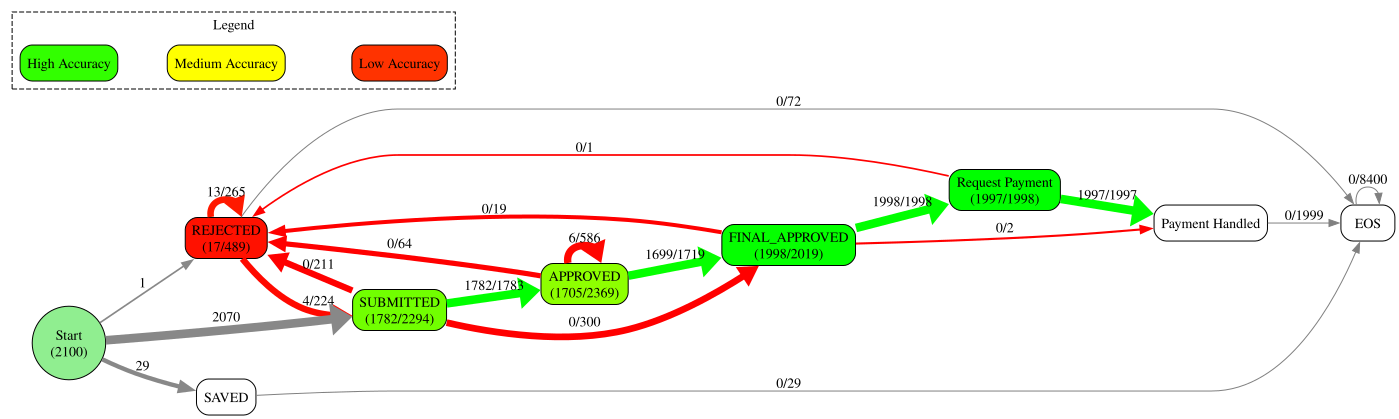

In [5]:
# Generate process map
dot = ppm.visualize(
    min_edge_count=1,
    show_counts=True,
    activity_name_map=activity_name_map,
    show_start_node=True
)
dot

## Interactive Explorer

In [6]:
# Interactive exploration
explorer = ppm.create_interactive_explorer(activity_name_map=activity_name_map)
explorer.show()